---
# PART 1: Stock Market Movement Analysis
---

## 1.1 Import Libraries

In [5]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn: Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# ── Scikit-learn: Models ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

# ── Statistical Analysis ──────────────────────────────────────────────────────
from scipy import stats

## 1.2 Load and Preprocess Stock Data

In [8]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
stock_df = pd.read_csv('BAI2007_Test_Dataset.csv')

print("Dataset Shape:", stock_df.shape)
print("\nFirst 5 Rows:")
stock_df.head()

Dataset Shape: (364, 7)

First 5 Rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2/1/2018,10477.54981,10495.20020,10404.65039,10442.20020,10442.20020,153400
1,3/1/2018,10482.65039,10503.59961,10429.54981,10443.20020,10443.20020,167300
2,4/1/2018,10469.40039,10513.00000,10441.45020,10504.79981,10504.79981,174900
3,5/1/2018,10534.25000,10566.09961,10520.09961,10558.84961,10558.84961,180900
4,8/1/2018,10591.70020,10631.20020,10588.54981,10623.59961,10623.59961,169000


In [10]:
# ── Data Info ─────────────────────────────────────────────────────────────────
print("Dataset Info:")
stock_df.info()
print("\nMissing Values:")
print(stock_df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       364 non-null    str    
 1   Open       364 non-null    float64
 2   High       364 non-null    float64
 3   Low        364 non-null    float64
 4   Close      364 non-null    float64
 5   Adj Close  364 non-null    float64
 6   Volume     364 non-null    int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 23.4 KB

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [14]:
# ── Parse Dates and Sort ──────────────────────────────────────────────────────
stock_df['Date'] = pd.to_datetime(stock_df['Date'], format='mixed', dayfirst=True)

stock_df.sort_values('Date', inplace=True)
stock_df.reset_index(drop=True, inplace=True)

# ── Drop rows with Volume = 0 (non-trading days) ──────────────────────────────
stock_df = stock_df[stock_df['Volume'] > 0].reset_index(drop=True)

print("Date range:", stock_df['Date'].min(), "→", stock_df['Date'].max())
print("Clean dataset shape:", stock_df.shape)
stock_df.head()

Date range: 2018-01-02 00:00:00 → 2019-06-28 00:00:00
Clean dataset shape: (350, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-02,10477.54981,10495.20020,10404.65039,10442.20020,10442.20020,153400
1,2018-01-03,10482.65039,10503.59961,10429.54981,10443.20020,10443.20020,167300
2,2018-01-04,10469.40039,10513.00000,10441.45020,10504.79981,10504.79981,174900
3,2018-01-05,10534.25000,10566.09961,10520.09961,10558.84961,10558.84961,180900
4,2018-01-08,10591.70020,10631.20020,10588.54981,10623.59961,10623.59961,169000


In [16]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
print("Descriptive Statistics:")
stock_df.describe().round(2)

Descriptive Statistics:


,Date,Open,High,Low,Close,Adj Close,Volume
count,350,350.00,350.00,350.00,350.00,350.00,350.00
mean,2018-09-28 18:39:05.142857,10956.80,11002.38,10892.24,10948.50,10948.50,292860.86
min,2018-01-02 00:00:00,9968.80,10027.70,9951.90,9998.05,9998.05,31200.00
25%,2018-05-14 06:00:00,10612.46,10645.69,10548.16,10596.90,10596.90,224275.00
50%,2018-09-26 12:00:00,10829.70,10868.50,10775.90,10817.35,10817.35,277500.00
75%,2019-02-14 18:00:00,11373.80,11403.64,11313.06,11358.71,11358.71,343325.00
max,2019-06-28 00:00:00,12052.65,12103.05,12005.85,12088.55,12088.55,719000.00
std,NaN,491.79,490.08,488.72,488.93,488.93,95189.44


## 1.3 Exploratory Data Analysis (EDA)

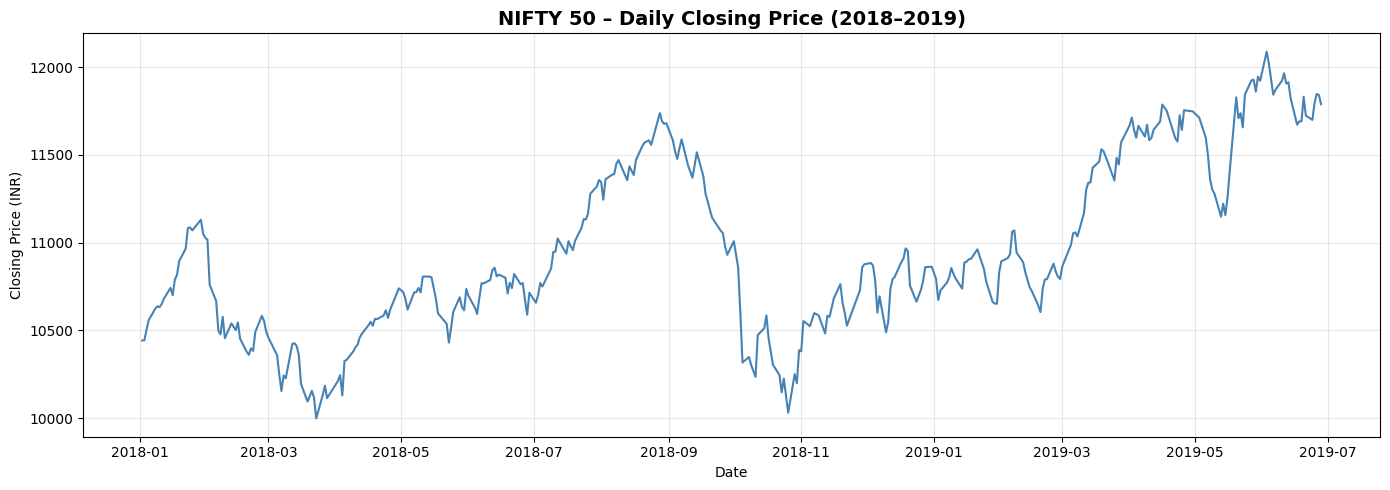

In [19]:
# ── NIFTY 50 Closing Price Over Time ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stock_df['Date'], stock_df['Close'], color='steelblue', linewidth=1.5)
ax.set_title('NIFTY 50 – Daily Closing Price (2018–2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (INR)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

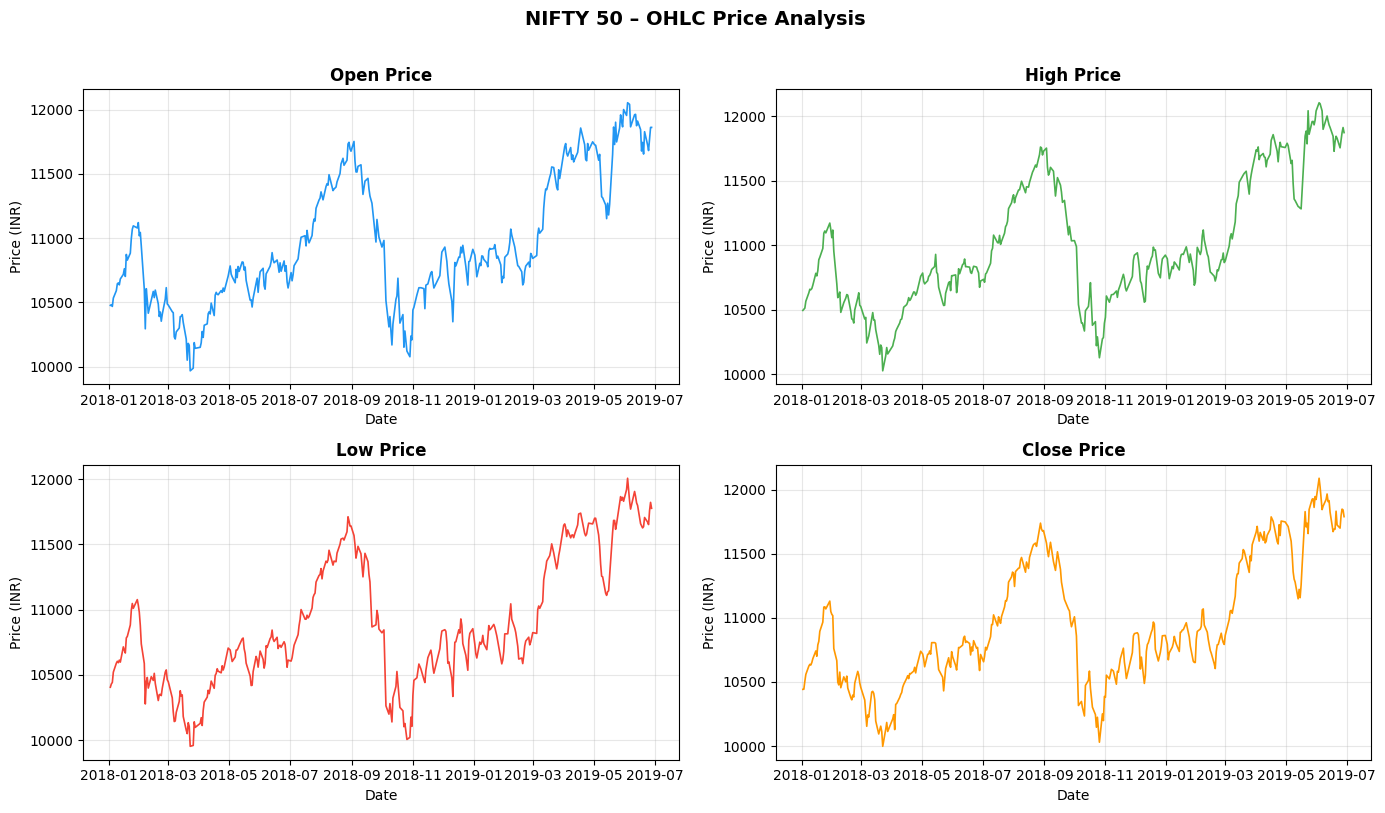

In [21]:
# ── OHLC Overview ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ['Open', 'High', 'Low', 'Close']
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']

for ax, col, color in zip(axes.flatten(), cols, colors):
    ax.plot(stock_df['Date'], stock_df[col], color=color, linewidth=1.2)
    ax.set_title(f'{col} Price', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (INR)')
    ax.grid(alpha=0.3)

plt.suptitle('NIFTY 50 – OHLC Price Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

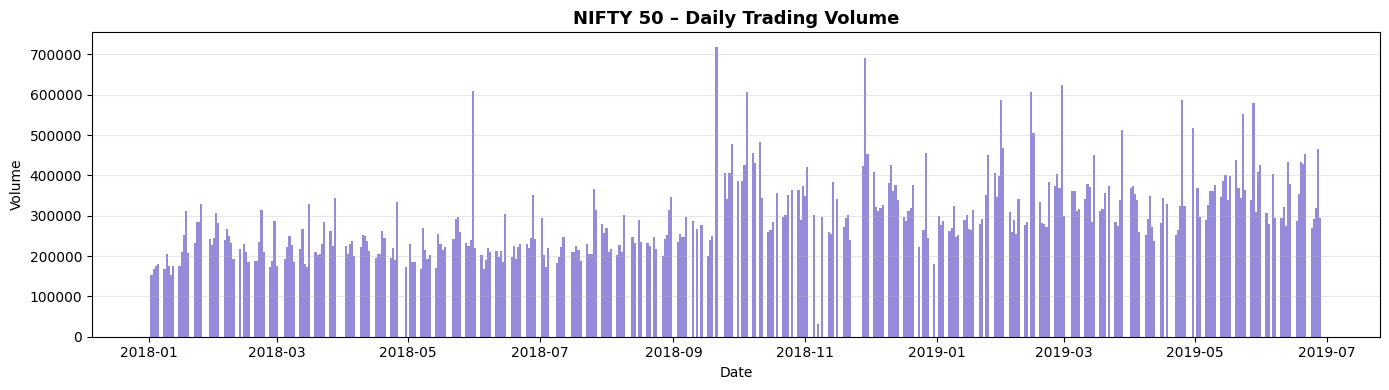

In [23]:
# ── Trading Volume Over Time ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(stock_df['Date'], stock_df['Volume'], color='slateblue', alpha=0.7, width=1)
ax.set_title('NIFTY 50 – Daily Trading Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volume')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

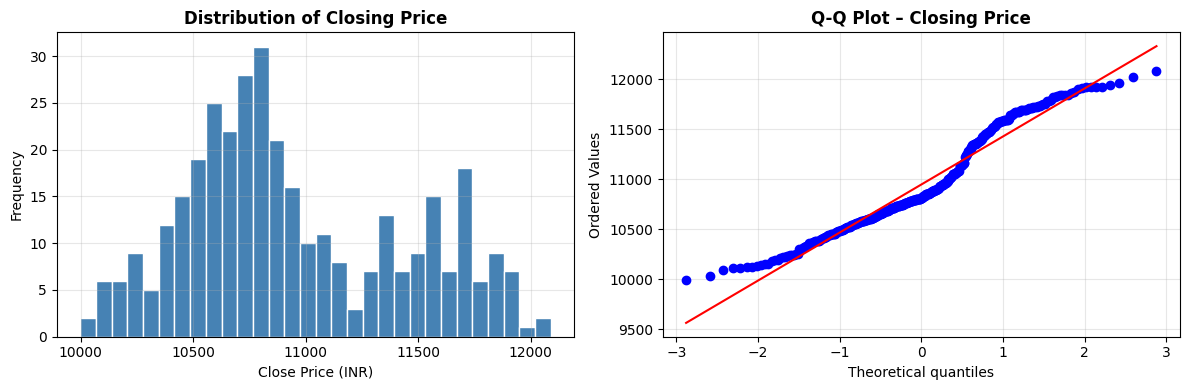

In [25]:
# ── Distribution of Closing Price ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(stock_df['Close'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Closing Price', fontweight='bold')
axes[0].set_xlabel('Close Price (INR)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

stats.probplot(stock_df['Close'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot – Closing Price', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.4 Feature Engineering

In [28]:
# ── Create Technical Features ─────────────────────────────────────────────────

# Daily Return (percentage change)
stock_df['Daily_Return'] = stock_df['Close'].pct_change() * 100

# Price Range (High - Low)
stock_df['Price_Range'] = stock_df['High'] - stock_df['Low']

# Moving Averages
stock_df['MA_7']  = stock_df['Close'].rolling(window=7).mean()
stock_df['MA_14'] = stock_df['Close'].rolling(window=14).mean()
stock_df['MA_30'] = stock_df['Close'].rolling(window=30).mean()

# Volatility (rolling standard deviation over 7 days)
stock_df['Volatility_7'] = stock_df['Daily_Return'].rolling(window=7).std()

# Lag Features (previous day and previous week close)
stock_df['Lag_1']  = stock_df['Close'].shift(1)
stock_df['Lag_7']  = stock_df['Close'].shift(7)

# Price Direction (target for classification: 1 = Up, 0 = Down/Flat)
stock_df['Price_Direction'] = (stock_df['Close'].diff() > 0).astype(int)

# Drop rows with NaN values created by rolling/lag operations
stock_df.dropna(inplace=True)
stock_df.reset_index(drop=True, inplace=True)

print("Feature engineering complete.")
print("Dataset shape after feature engineering:", stock_df.shape)
stock_df[['Date', 'Close', 'Daily_Return', 'MA_7', 'MA_14', 'Volatility_7', 'Lag_1', 'Price_Direction']].head(10)

Feature engineering complete.
Dataset shape after feature engineering: (321, 16)


,Date,Close,Daily_Return,MA_7,MA_14,Volatility_7,Lag_1,Price_Direction
0,2018-02-14,10500.90039,-0.368601,10530.564316,10775.346541,0.957501,10539.75000,0
1,2018-02-15,10545.50000,0.424722,10513.271486,10736.739399,0.963595,10500.90039,1
2,2018-02-16,10452.29981,-0.883791,10506.707173,10692.642929,0.817967,10545.50000,0
3,2018-02-19,10378.40039,-0.707016,10492.664343,10638.928643,0.854030,10452.29981,0
4,2018-02-20,10360.40039,-0.173437,10461.743026,10589.696500,0.708681,10378.40039,0
5,2018-02-21,10397.45020,0.357610,10453.528740,10544.678643,0.628688,10360.40039,1
6,2018-02-22,10382.70020,-0.141862,10431.093054,10499.378629,0.492804,10397.45020,0
7,2018-02-23,10491.04981,1.043559,10429.685829,10480.125072,0.674232,10382.70020,1
8,2018-02-26,10582.59961,0.872647,10434.985773,10474.128629,0.740525,10491.04981,1
9,2018-02-27,10554.29981,-0.267418,10449.557201,10478.132187,0.640528,10582.59961,0


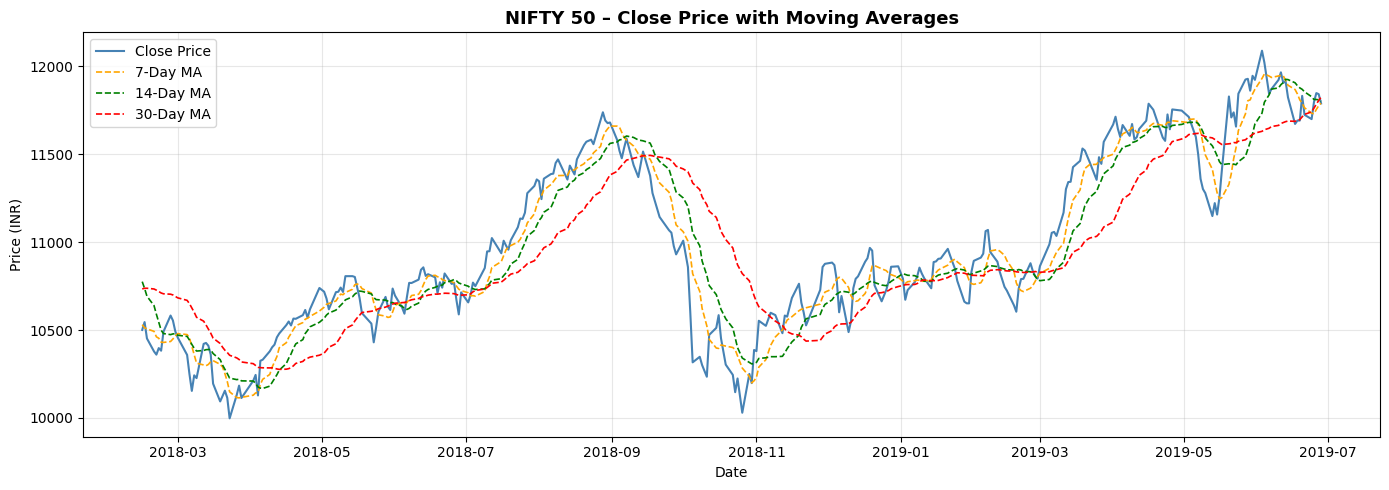

In [30]:
# ── Moving Averages Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(stock_df['Date'], stock_df['Close'], label='Close Price', color='steelblue', linewidth=1.5)
ax.plot(stock_df['Date'], stock_df['MA_7'],  label='7-Day MA',   color='orange',    linewidth=1.2, linestyle='--')
ax.plot(stock_df['Date'], stock_df['MA_14'], label='14-Day MA',  color='green',     linewidth=1.2, linestyle='--')
ax.plot(stock_df['Date'], stock_df['MA_30'], label='30-Day MA',  color='red',       linewidth=1.2, linestyle='--')
ax.set_title('NIFTY 50 – Close Price with Moving Averages', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (INR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

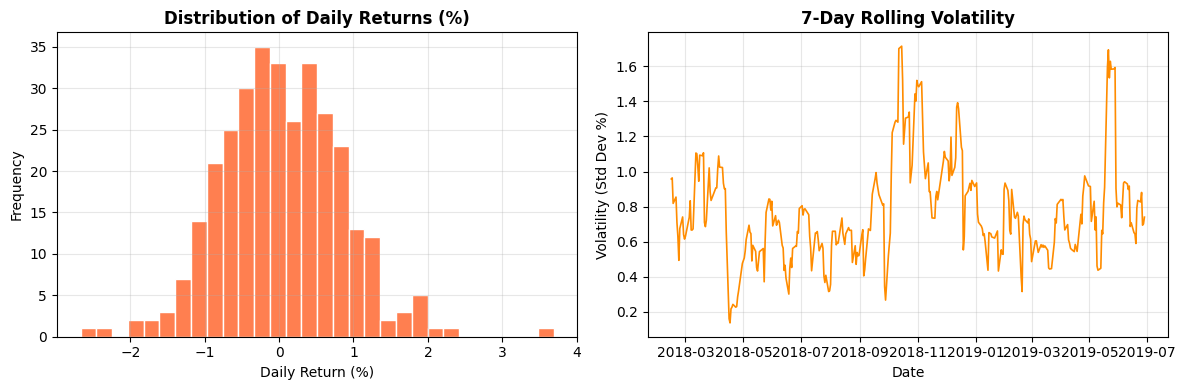

In [32]:
# ── Daily Return Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(stock_df['Daily_Return'], bins=30, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Daily Returns (%)', fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].plot(stock_df['Date'], stock_df['Volatility_7'], color='darkorange', linewidth=1.2)
axes[1].set_title('7-Day Rolling Volatility', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility (Std Dev %)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.5 Correlation Analysis (Pearson)

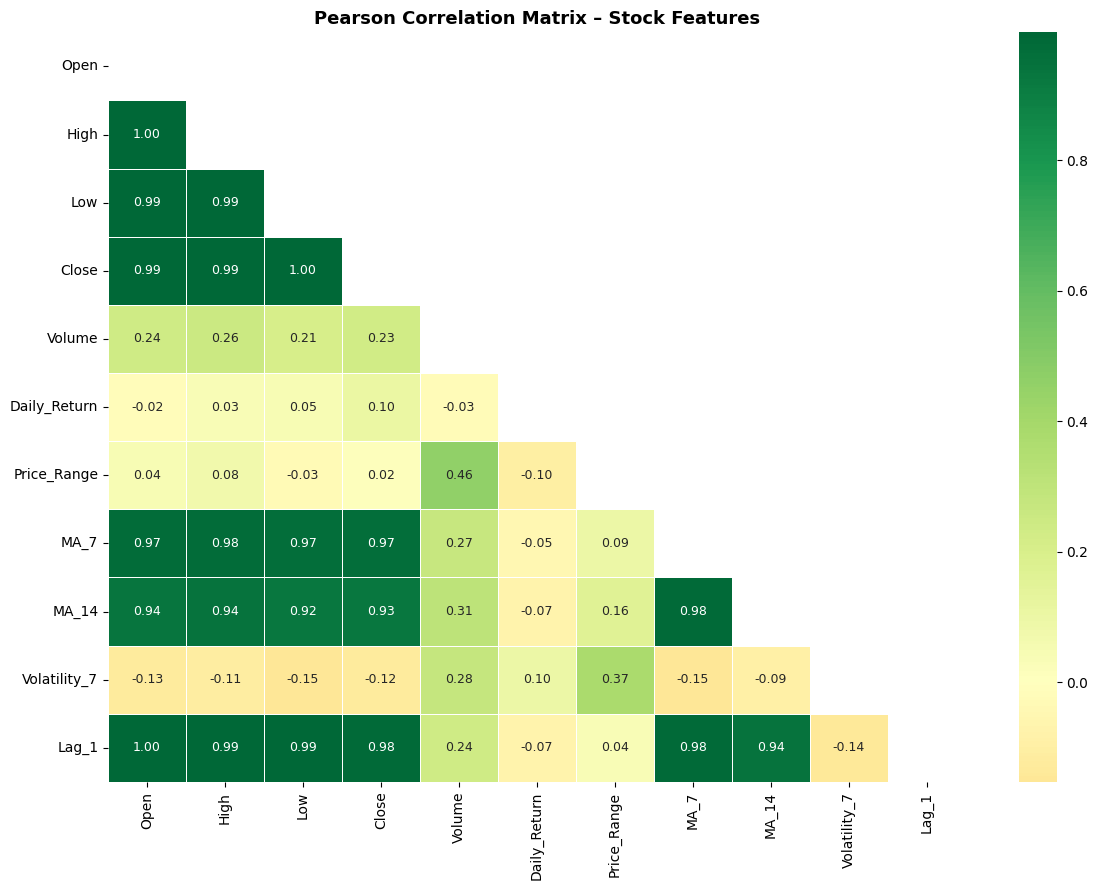

In [35]:
# ── Pearson Correlation Matrix ────────────────────────────────────────────────
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
             'Daily_Return', 'Price_Range', 'MA_7', 'MA_14', 'Volatility_7', 'Lag_1']

corr_matrix = stock_df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix – Stock Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

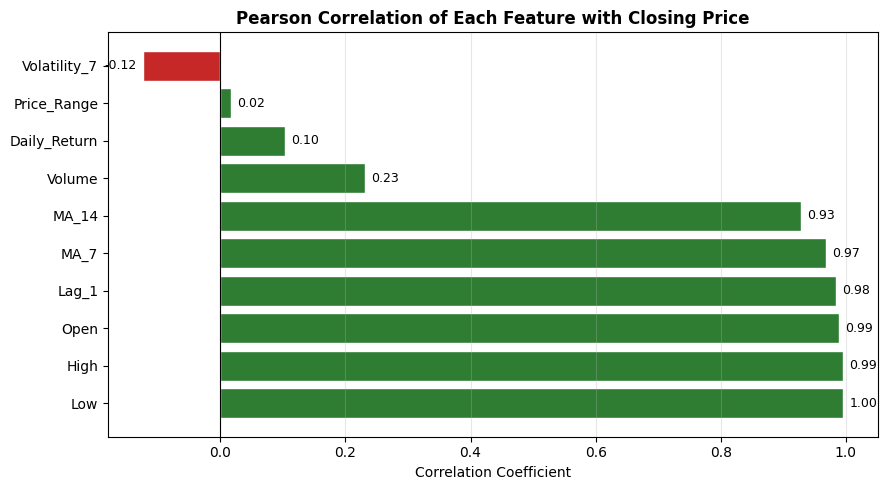


Correlation values with Closing Price:
Low             0.9957
High            0.9949
Open            0.9886
Lag_1           0.9844
MA_7            0.9680
MA_14           0.9285
Volume          0.2319
Daily_Return    0.1037
Price_Range     0.0173
Volatility_7   -0.1234


In [37]:
# ── Pearson Correlation of Features vs Closing Price ──────────────────────────
corr_with_close = corr_matrix['Close'].drop('Close').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2e7d32' if v > 0 else '#c62828' for v in corr_with_close.values]
bars = ax.barh(corr_with_close.index, corr_with_close.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Each Feature with Closing Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, corr_with_close.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nCorrelation values with Closing Price:")
print(corr_with_close.round(4).to_string())

In [39]:
# ── Statistical Significance Test (p-values) ──────────────────────────────────
print("Pearson Correlation & P-value (Feature vs Close Price):\n")
print(f"{'Feature':<18} {'r':>8} {'p-value':>12} {'Significant?':>14}")
print("-" * 55)

for col in corr_cols:
    if col == 'Close':
        continue
    r, p = stats.pearsonr(stock_df[col], stock_df['Close'])
    sig = "Yes ✓" if p < 0.05 else "No"
    print(f"{col:<18} {r:>8.4f} {p:>12.4e} {sig:>14}")

Pearson Correlation & P-value (Feature vs Close Price):

Feature                   r      p-value   Significant?
-------------------------------------------------------
Open                 0.9886  2.5393e-264          Yes ✓
High                 0.9949  1.7460e-320          Yes ✓
Low                  0.9957   0.0000e+00          Yes ✓
Volume               0.2319   2.7250e-05          Yes ✓
Daily_Return         0.1037   6.3605e-02             No
Price_Range          0.0173   7.5795e-01             No
MA_7                 0.9680  1.4251e-193          Yes ✓
MA_14                0.9285  2.5443e-139          Yes ✓
Volatility_7        -0.1234   2.7039e-02          Yes ✓
Lag_1                0.9844  1.0094e-242          Yes ✓


## 1.6 Machine Learning Models

In [42]:
# ── Prepare Features and Target ───────────────────────────────────────────────
features = ['Open', 'High', 'Low', 'Volume', 'Daily_Return',
            'Price_Range', 'MA_7', 'MA_14', 'Volatility_7', 'Lag_1', 'Lag_7']
target_reg   = 'Close'           # Regression target
target_class = 'Price_Direction' # Classification target

X = stock_df[features]
y_reg   = stock_df[target_reg]
y_class = stock_df[target_class]

# ── Normalise Features ────────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/Test Split (80/20) ──────────────────────────────────────────────────
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, shuffle=False
)
_, _, y_train_cls, y_test_cls = train_test_split(
    X_scaled, y_class, test_size=0.2, shuffle=False
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Test set size     : {X_test.shape[0]} samples")

Training set size : 256 samples
Test set size     : 65 samples


### 1.6.1 Linear Regression

In [45]:
# ── Train Linear Regression ───────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_reg)
lr_pred = lr_model.predict(X_test)

# Metrics
lr_mse  = mean_squared_error(y_test_reg, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae  = mean_absolute_error(y_test_reg, lr_pred)
lr_r2   = r2_score(y_test_reg, lr_pred)

print("Linear Regression – Regression Results")
print(f"  MSE  : {lr_mse:.4f}")
print(f"  RMSE : {lr_rmse:.4f}")
print(f"  MAE  : {lr_mae:.4f}")
print(f"  R²   : {lr_r2:.4f}")

Linear Regression – Regression Results
  MSE  : 71.6372
  RMSE : 8.4639
  MAE  : 6.7145
  R²   : 0.9984


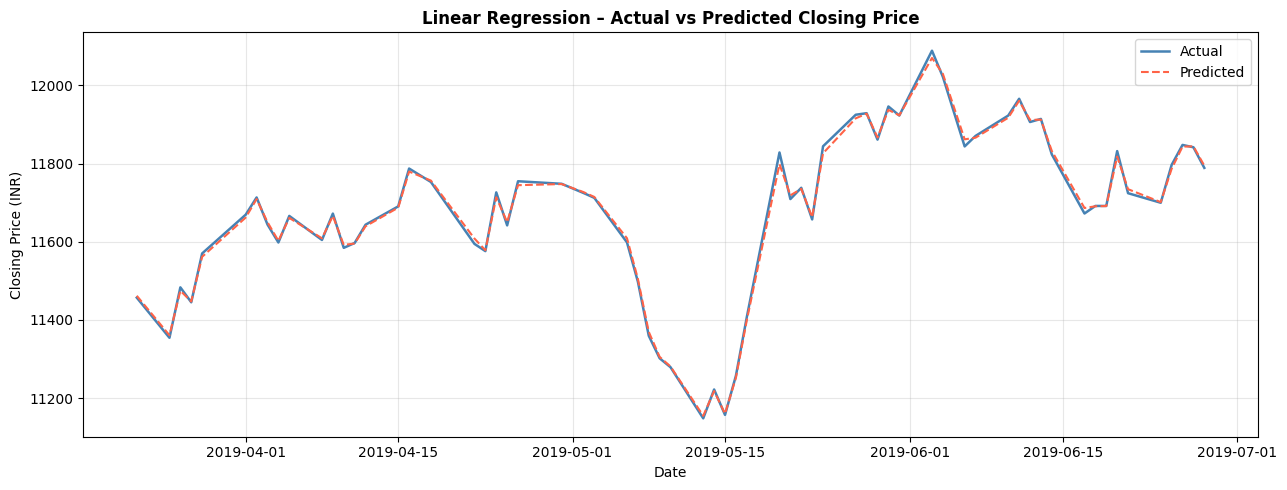

In [47]:
# ── Actual vs Predicted – Linear Regression ───────────────────────────────────
test_dates = stock_df['Date'].iloc[-len(y_test_reg):].values

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test_reg.values, label='Actual',    color='steelblue', linewidth=1.8)
ax.plot(test_dates, lr_pred,           label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
ax.set_title('Linear Regression – Actual vs Predicted Closing Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (INR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6.2 Random Forest Regressor

In [50]:
# ── Train Random Forest Regressor ─────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_reg)
rf_pred = rf_model.predict(X_test)

rf_mse  = mean_squared_error(y_test_reg, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test_reg, rf_pred)
rf_r2   = r2_score(y_test_reg, rf_pred)

print("Random Forest Regressor – Results")
print(f"  MSE  : {rf_mse:.4f}")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  R²   : {rf_r2:.4f}")

Random Forest Regressor – Results
  MSE  : 16272.6039
  RMSE : 127.5641
  MAE  : 91.9278
  R²   : 0.6312


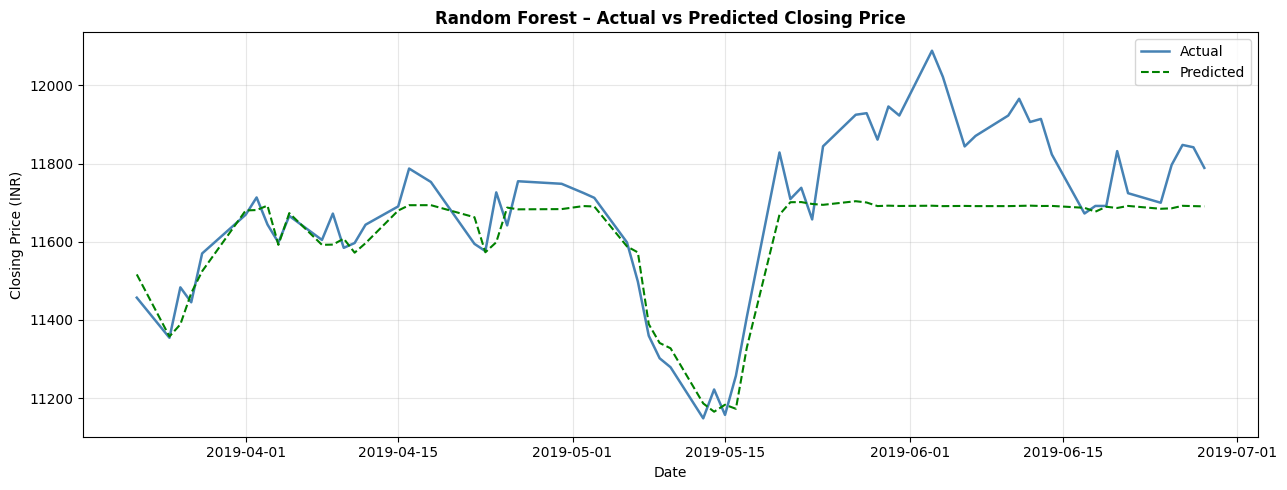

In [52]:
# ── Actual vs Predicted – Random Forest ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test_reg.values, label='Actual',    color='steelblue', linewidth=1.8)
ax.plot(test_dates, rf_pred,           label='Predicted', color='green',     linewidth=1.5, linestyle='--')
ax.set_title('Random Forest – Actual vs Predicted Closing Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (INR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6.3 Support Vector Machine (SVR)

In [57]:
# ── Train SVR ─────────────────────────────────────────────────────────────────
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train, y_train_reg)
svr_pred = svr_model.predict(X_test)

svr_mse  = mean_squared_error(y_test_reg, svr_pred)
svr_rmse = np.sqrt(svr_mse)
svr_mae  = mean_absolute_error(y_test_reg, svr_pred)
svr_r2   = r2_score(y_test_reg, svr_pred)

print("Support Vector Regressor (SVR) – Results")
print(f"  MSE  : {svr_mse:.4f}")
print(f"  RMSE : {svr_rmse:.4f}")
print(f"  MAE  : {svr_mae:.4f}")
print(f"  R²   : {svr_r2:.4f}")

Support Vector Regressor (SVR) – Results
  MSE  : 18027.8038
  RMSE : 134.2677
  MAE  : 112.3147
  R²   : 0.5914


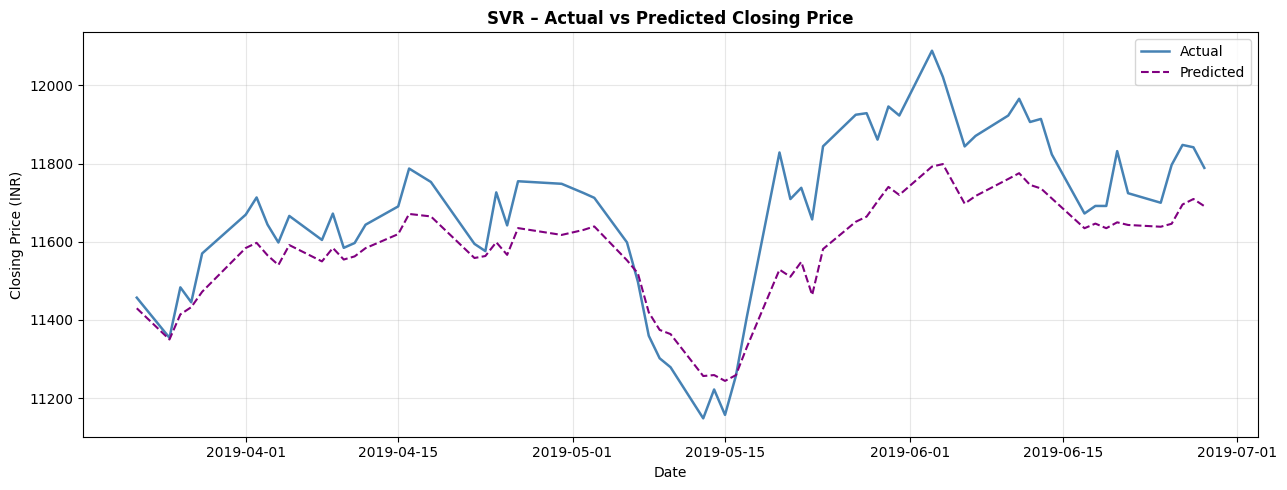

In [59]:
# ── Actual vs Predicted – SVR ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test_reg.values, label='Actual',    color='steelblue', linewidth=1.8)
ax.plot(test_dates, svr_pred,          label='Predicted', color='purple',    linewidth=1.5, linestyle='--')
ax.set_title('SVR – Actual vs Predicted Closing Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (INR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 1.7 Model Evaluation – Comparison

In [62]:
# ── Regression Model Comparison Table ────────────────────────────────────────
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR'],
    'MSE':   [round(lr_mse, 4),  round(rf_mse, 4),  round(svr_mse, 4)],
    'RMSE':  [round(lr_rmse, 4), round(rf_rmse, 4), round(svr_rmse, 4)],
    'MAE':   [round(lr_mae, 4),  round(rf_mae, 4),  round(svr_mae, 4)],
    'R²':    [round(lr_r2, 4),   round(rf_r2, 4),   round(svr_r2, 4)]
})
print("Regression Model Comparison:")
results_reg

Regression Model Comparison:


,Model,MSE,RMSE,MAE,R²
0,Linear Regression,71.6372,8.4639,6.7145,0.9984
1,Random Forest,16272.6039,127.5641,91.9278,0.6312
2,SVR,18027.8038,134.2677,112.3147,0.5914


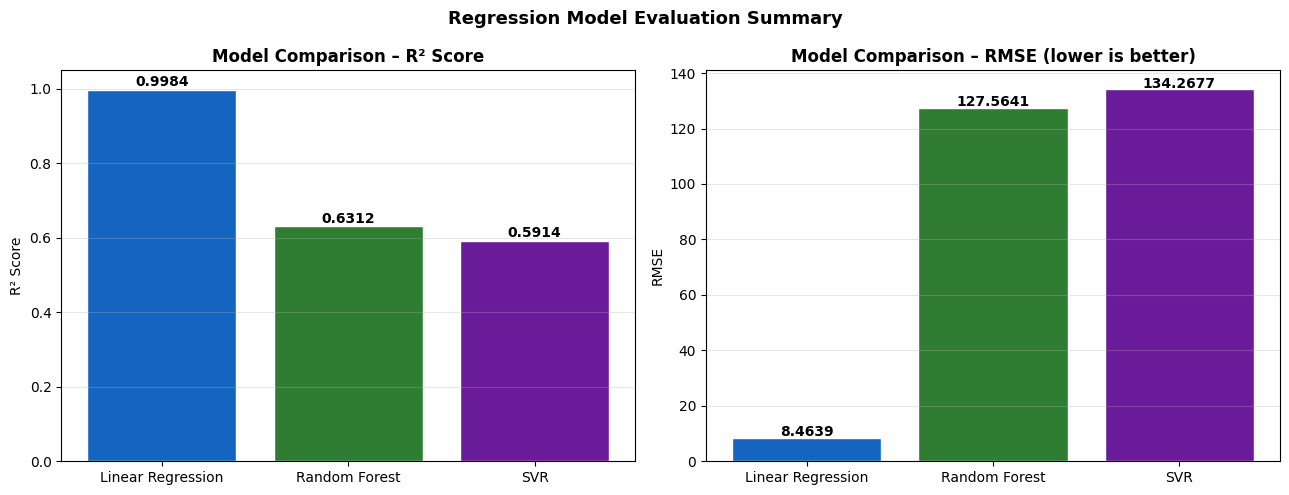

In [64]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models   = results_reg['Model']
bar_colors = ['#1565C0', '#2E7D32', '#6A1B9A']

# R² Score
axes[0].bar(models, results_reg['R²'], color=bar_colors, edgecolor='white')
axes[0].set_title('Model Comparison – R² Score', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(results_reg['R²']):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(models, results_reg['RMSE'], color=bar_colors, edgecolor='white')
axes[1].set_title('Model Comparison – RMSE (lower is better)', fontweight='bold')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(results_reg['RMSE']):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Regression Model Evaluation Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

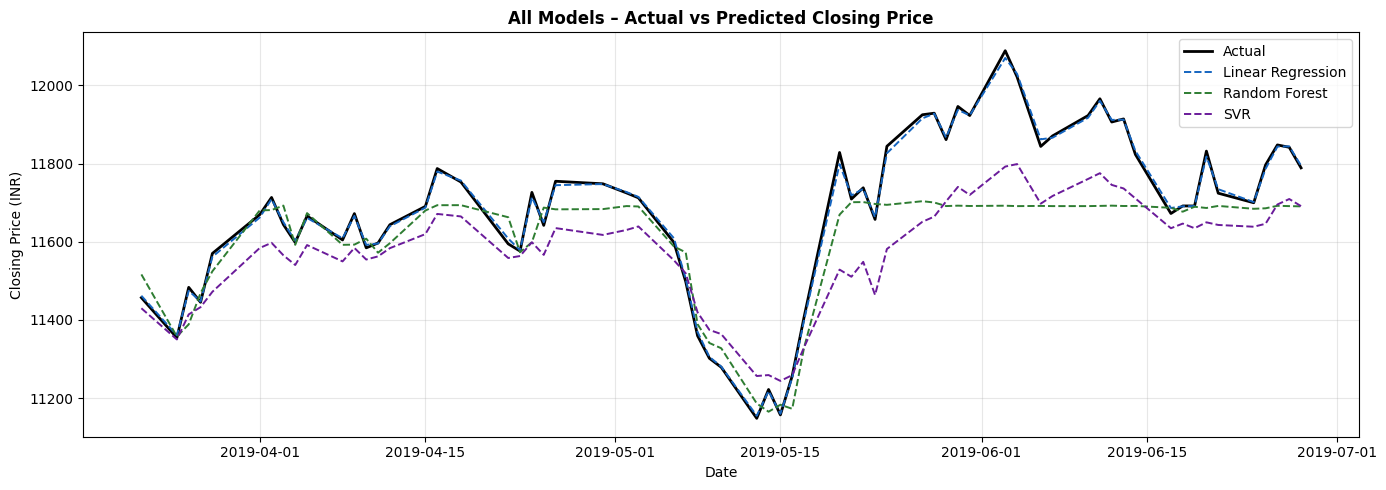

In [66]:
# ── All Models Overlay – Actual vs Predicted ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, y_test_reg.values, label='Actual',            color='black',    linewidth=2.0)
ax.plot(test_dates, lr_pred,           label='Linear Regression', color='#1565C0',  linewidth=1.4, linestyle='--')
ax.plot(test_dates, rf_pred,           label='Random Forest',     color='#2E7D32',  linewidth=1.4, linestyle='--')
ax.plot(test_dates, svr_pred,          label='SVR',               color='#6A1B9A',  linewidth=1.4, linestyle='--')
ax.set_title('All Models – Actual vs Predicted Closing Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (INR)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# PART 2: Sentiment Analysis (Twitter Dataset)
---

## 2.1 Import Libraries

In [72]:
# ── NLP Libraries ─────────────────────────────────────────────────────────────
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ── Download NLTK Resources ───────────────────────────────────────────────────
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('vader_lexicon',quiet=True)



True

## 2.2 Load and Preprocess Tweet Data

In [75]:
# ── Load Tweets Dataset ───────────────────────────────────────────────────────
tweets_df = pd.read_csv('tweets.csv')

print("Tweets Dataset Shape:", tweets_df.shape)
print("\nFirst 5 rows:")
tweets_df.head()

Tweets Dataset Shape: (1000, 7)

First 5 rows:


,Tweet ID,Text,User,Created At,Likes,Retweets,Sentiment
0,4.492120e+17,Feeling grateful for my friends and family.,werickson,1/13/2023 0:35,156,489,positive
1,5.190370e+17,Going for a walk in the park.,jennybutler,2/16/2023 6:24,223,788,neutral
2,7.760230e+17,I hate it when things don't go my way.,william88,1/24/2023 18:12,332,860,negative
3,6.747500e+17,I hate it when things don't go my way.,lawrencebauer,2/9/2023 7:14,388,881,negative
4,8.597260e+17,This is the best day ever!,gerald07,2/28/2023 6:55,255,567,positive


In [77]:
# ── Data Info and Missing Values ──────────────────────────────────────────────
print("Dataset Info:")
tweets_df.info()
print("\nMissing Values:")
print(tweets_df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tweet ID    1000 non-null   float64
 1   Text        1000 non-null   str    
 2   User        1000 non-null   str    
 3   Created At  1000 non-null   str    
 4   Likes       1000 non-null   int64  
 5   Retweets    1000 non-null   int64  
 6   Sentiment   1000 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 114.1 KB

Missing Values:
Tweet ID      0
Text          0
User          0
Created At    0
Likes         0
Retweets      0
Sentiment     0
dtype: int64


In [79]:
# ── Clean Column Names and Parse Dates ────────────────────────────────────────
tweets_df.columns = tweets_df.columns.str.strip()
tweets_df['Created At'] = pd.to_datetime(tweets_df['Created At'], errors='coerce')
tweets_df['Sentiment']  = tweets_df['Sentiment'].str.strip().str.lower()
tweets_df.dropna(subset=['Text', 'Sentiment'], inplace=True)
tweets_df.reset_index(drop=True, inplace=True)

print("Sentiment class distribution:")
print(tweets_df['Sentiment'].value_counts())
print("\nClean shape:", tweets_df.shape)

Sentiment class distribution:
Sentiment
negative    422
positive    332
neutral     246
Name: count, dtype: int64

Clean shape: (1000, 7)


## 2.3 Exploratory Data Analysis (EDA) – Tweets

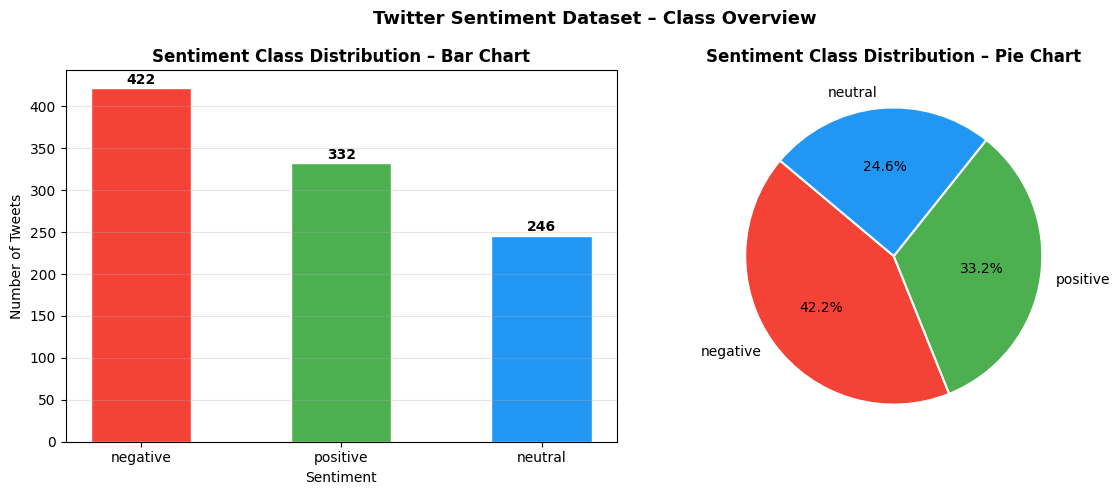

In [82]:
# ── Sentiment Class Distribution ──────────────────────────────────────────────
sent_counts = tweets_df['Sentiment'].value_counts()
sent_colors = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}
colors_list = [sent_colors[s] for s in sent_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(sent_counts.index, sent_counts.values, color=colors_list, edgecolor='white', width=0.5)
axes[0].set_title('Sentiment Class Distribution – Bar Chart', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=colors_list, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sentiment Class Distribution – Pie Chart', fontweight='bold')

plt.suptitle('Twitter Sentiment Dataset – Class Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

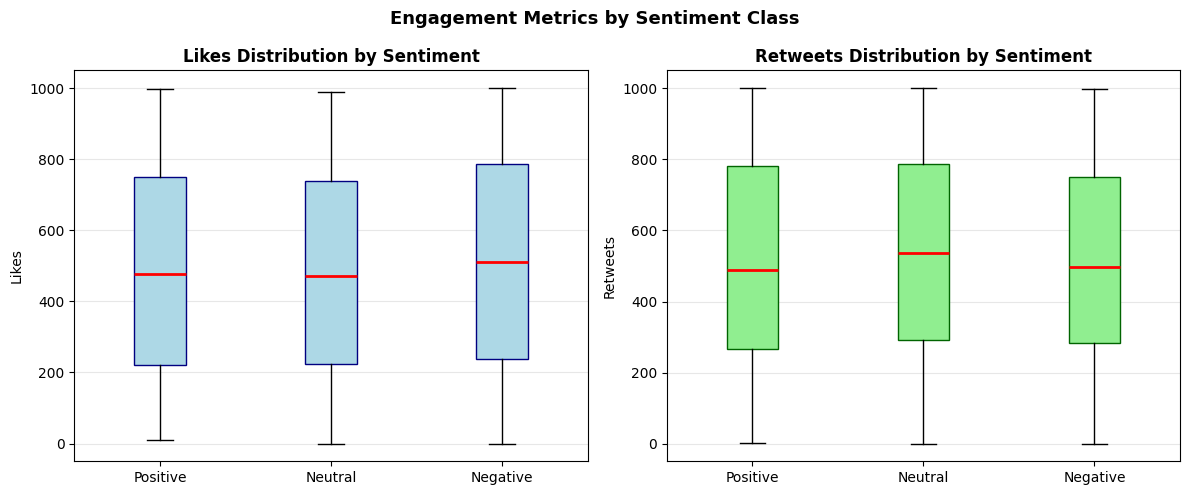

In [84]:
# ── Likes and Retweets by Sentiment ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tweet_groups = [tweets_df[tweets_df['Sentiment'] == s]['Likes'].values
                for s in ['positive', 'neutral', 'negative']]

axes[0].boxplot(tweet_groups, labels=['Positive', 'Neutral', 'Negative'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Likes Distribution by Sentiment', fontweight='bold')
axes[0].set_ylabel('Likes')
axes[0].grid(axis='y', alpha=0.3)

rt_groups = [tweets_df[tweets_df['Sentiment'] == s]['Retweets'].values
             for s in ['positive', 'neutral', 'negative']]

axes[1].boxplot(rt_groups, labels=['Positive', 'Neutral', 'Negative'],
                patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Retweets Distribution by Sentiment', fontweight='bold')
axes[1].set_ylabel('Retweets')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Engagement Metrics by Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

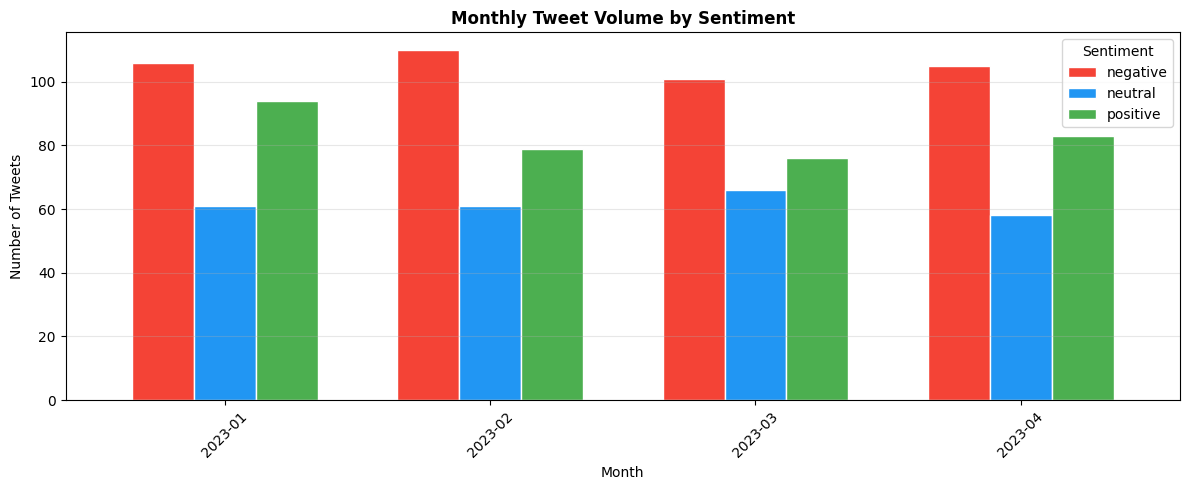

In [86]:
# ── Tweet Volume Over Time by Sentiment ───────────────────────────────────────
tweets_df['Month'] = tweets_df['Created At'].dt.to_period('M')
monthly_sent = tweets_df.groupby(['Month', 'Sentiment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
monthly_sent.plot(kind='bar', ax=ax,
                  color=['#F44336', '#2196F3', '#4CAF50'],
                  edgecolor='white', width=0.7)
ax.set_title('Monthly Tweet Volume by Sentiment', fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Tweets')
ax.legend(title='Sentiment')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.4 Text Preprocessing (NLP Pipeline)

In [89]:
# ── NLP Preprocessing Function ────────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def preprocess_text(text):
    """Clean and normalise tweet text for NLP analysis."""
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation and digits
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    # Tokenise
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

tweets_df['Clean_Text'] = tweets_df['Text'].apply(preprocess_text)

print("Sample preprocessed tweets:")
tweets_df[['Text', 'Clean_Text', 'Sentiment']].head(6)

Sample preprocessed tweets:


,Text,Clean_Text,Sentiment
0,Feeling grateful for my friends and family.,feeling grateful friend family,positive
1,Going for a walk in the park.,going walk park,neutral
2,I hate it when things don't go my way.,hate thing dont way,negative
3,I hate it when things don't go my way.,hate thing dont way,negative
4,This is the best day ever!,best day ever,positive
5,Feeling grateful for my friends and family.,feeling grateful friend family,positive


## 2.5 Sentiment Scoring with VADER

In [94]:
# ── VADER Sentiment Scoring ───────────────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return scores['neg'], scores['neu'], scores['pos'], scores['compound']

tweets_df[['VADER_Neg', 'VADER_Neu', 'VADER_Pos', 'VADER_Compound']] = \
    tweets_df['Text'].apply(lambda t: pd.Series(get_vader_scores(t)))

# Map compound score to sentiment label
def compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

tweets_df['VADER_Label'] = tweets_df['VADER_Compound'].apply(compound_to_label)

print("VADER scoring complete.")
tweets_df[['Text', 'Sentiment', 'VADER_Compound', 'VADER_Label']].head(8)

VADER scoring complete.


,Text,Sentiment,VADER_Compound,VADER_Label
0,Feeling grateful for my friends and family.,positive,0.7650,positive
1,Going for a walk in the park.,neutral,0.0000,neutral
2,I hate it when things don't go my way.,negative,-0.5719,negative
3,I hate it when things don't go my way.,negative,-0.5719,negative
4,This is the best day ever!,positive,0.6696,positive
5,Feeling grateful for my friends and family.,positive,0.7650,positive
6,Feeling grateful for my friends and family.,positive,0.7650,positive
7,Feeling disappointed in myself.,negative,-0.3818,negative


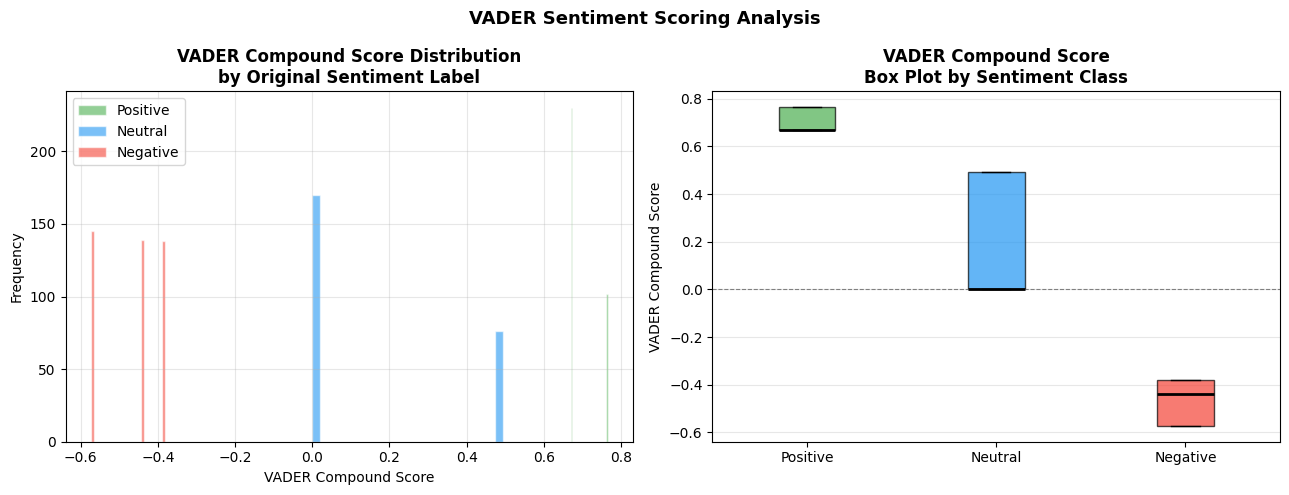

In [96]:
# ── VADER Compound Score Distribution by Sentiment ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sent, color in [('positive', '#4CAF50'), ('neutral', '#2196F3'), ('negative', '#F44336')]:
    subset = tweets_df[tweets_df['Sentiment'] == sent]['VADER_Compound']
    axes[0].hist(subset, bins=25, alpha=0.6, label=sent.capitalize(), color=color, edgecolor='white')

axes[0].set_title('VADER Compound Score Distribution\nby Original Sentiment Label', fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
pos_scores  = tweets_df[tweets_df['Sentiment'] == 'positive']['VADER_Compound'].values
neu_scores  = tweets_df[tweets_df['Sentiment'] == 'neutral']['VADER_Compound'].values
neg_scores  = tweets_df[tweets_df['Sentiment'] == 'negative']['VADER_Compound'].values

bp = axes[1].boxplot([pos_scores, neu_scores, neg_scores],
                     labels=['Positive', 'Neutral', 'Negative'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4CAF50', '#2196F3', '#F44336']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('VADER Compound Score\nBox Plot by Sentiment Class', fontweight='bold')
axes[1].set_ylabel('VADER Compound Score')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('VADER Sentiment Scoring Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
# ── VADER Accuracy vs Original Labels ─────────────────────────────────────────
vader_acc = accuracy_score(tweets_df['Sentiment'], tweets_df['VADER_Label'])
print(f"VADER Accuracy vs Original Labels: {vader_acc:.4f} ({vader_acc*100:.2f}%)")
print("\nVADER Classification Report:")
print(classification_report(tweets_df['Sentiment'], tweets_df['VADER_Label'],
                             target_names=['negative', 'neutral', 'positive']))

VADER Accuracy vs Original Labels: 0.9240 (92.40%)

VADER Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       422
     neutral       1.00      0.69      0.82       246
    positive       0.81      1.00      0.90       332

    accuracy                           0.92      1000
   macro avg       0.94      0.90      0.90      1000
weighted avg       0.94      0.92      0.92      1000



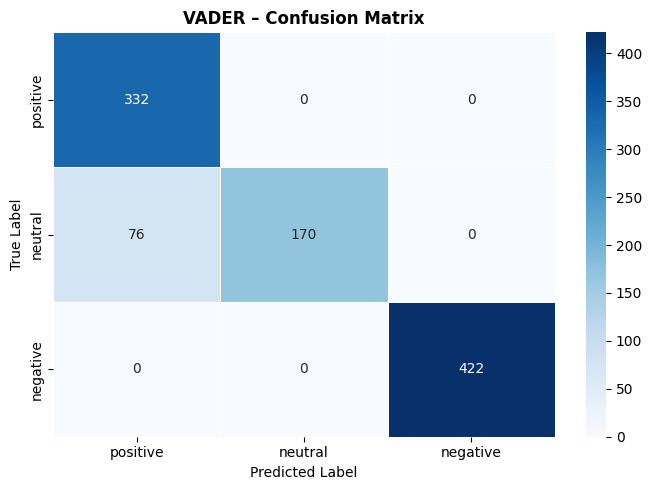

In [100]:
# ── VADER Confusion Matrix ────────────────────────────────────────────────────
labels_order = ['positive', 'neutral', 'negative']
cm_vader = confusion_matrix(tweets_df['Sentiment'], tweets_df['VADER_Label'],
                            labels=labels_order)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            linewidths=0.5, ax=ax)
ax.set_title('VADER – Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## 2.6 Sentiment Classification Models (ML)

In [103]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

le = LabelEncoder()
tweets_df['Sentiment_Encoded'] = le.fit_transform(tweets_df['Sentiment'])

X_tfidf = tfidf.fit_transform(tweets_df['Clean_Text'])
y_sent  = tweets_df['Sentiment_Encoded']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tfidf, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

print(f"TF-IDF matrix shape  : {X_tfidf.shape}")
print(f"Training samples     : {X_tr.shape[0]}")
print(f"Test samples         : {X_te.shape[0]}")
print(f"Label encoding       : {dict(zip(le.classes_, le.transform(le.classes_)))}")

TF-IDF matrix shape  : (1000, 39)
Training samples     : 800
Test samples         : 200
Label encoding       : {'negative': 0, 'neutral': 1, 'positive': 2}


In [105]:
# ── Train All Classifiers ─────────────────────────────────────────────────────
classifiers = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(kernel='linear', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

clf_results = {}

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    preds   = clf.predict(X_te)
    acc     = accuracy_score(y_te, preds)
    clf_results[name] = {'model': clf, 'preds': preds, 'accuracy': acc}
    print(f"{name:<25} Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Naive Bayes               Accuracy: 1.0000 (100.00%)
Logistic Regression       Accuracy: 1.0000 (100.00%)
SVM                       Accuracy: 1.0000 (100.00%)
Random Forest             Accuracy: 1.0000 (100.00%)


In [107]:
# ── Detailed Classification Reports ──────────────────────────────────────────
for name, res in clf_results.items():
    print(f"\n{'='*55}")
    print(f"  {name} – Classification Report")
    print('='*55)
    print(classification_report(y_te, res['preds'],
                                target_names=le.classes_))


  Naive Bayes – Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        85
     neutral       1.00      1.00      1.00        49
    positive       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


  Logistic Regression – Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        85
     neutral       1.00      1.00      1.00        49
    positive       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


  SVM – Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        85
     neutral

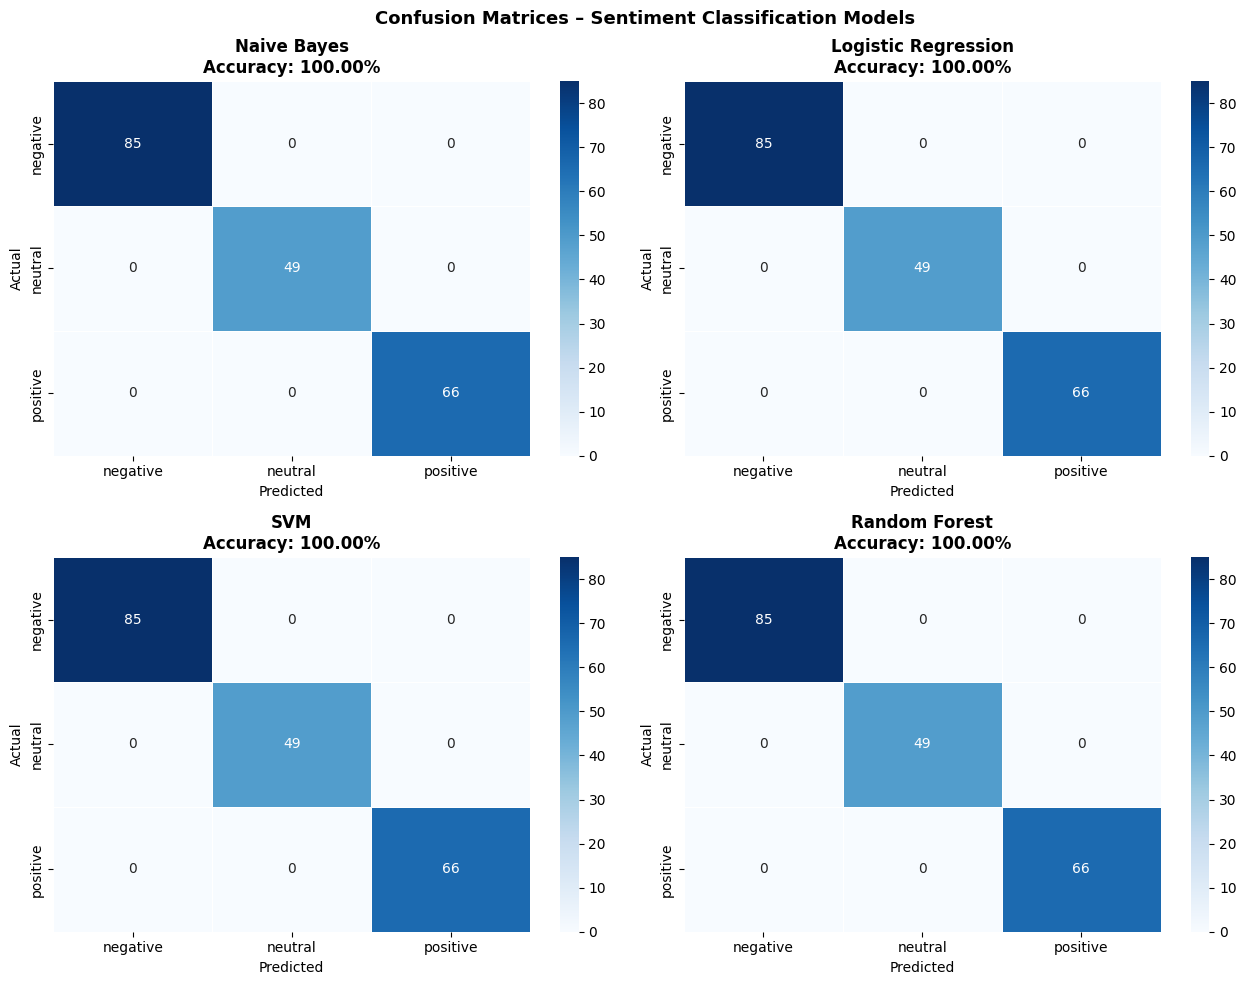

In [109]:
# ── Confusion Matrices – All Classifiers ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (name, res) in zip(axes.flatten(), clf_results.items()):
    cm = confusion_matrix(y_te, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices – Sentiment Classification Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

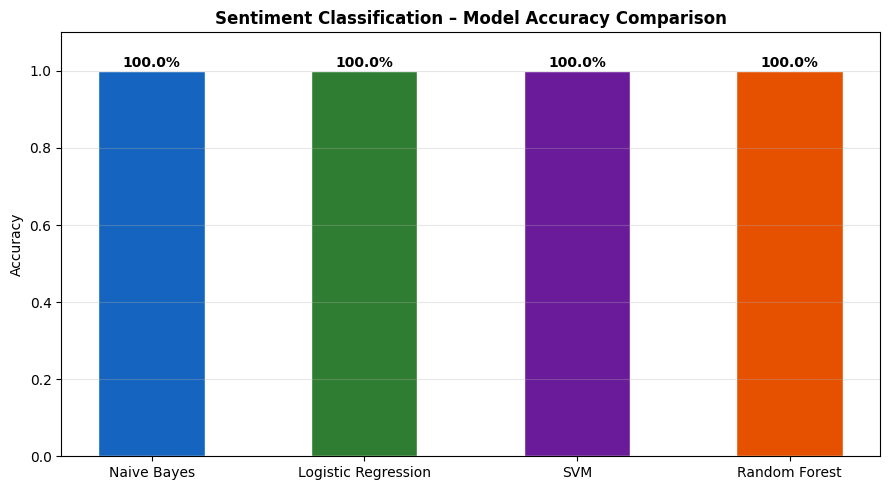

In [111]:
# ── Classifier Accuracy Comparison ───────────────────────────────────────────
clf_names = list(clf_results.keys())
clf_accs  = [clf_results[n]['accuracy'] for n in clf_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(clf_names, clf_accs,
              color=['#1565C0', '#2E7D32', '#6A1B9A', '#E65100'],
              edgecolor='white', width=0.5)
ax.set_title('Sentiment Classification – Model Accuracy Comparison',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
for bar, acc in zip(bars, clf_accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
            f'{acc*100:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2.7 Correlation Between Sentiment and Stock Price Movement

In [114]:
# ── Aggregate Daily Sentiment Scores from Tweets ──────────────────────────────
# Group tweets by date and compute mean VADER compound score per day
tweets_df['Date_Only'] = tweets_df['Created At'].dt.date
daily_sentiment = tweets_df.groupby('Date_Only').agg(
    Avg_Compound    = ('VADER_Compound', 'mean'),
    Tweet_Count     = ('VADER_Compound', 'count'),
    Positive_Ratio  = ('VADER_Label', lambda x: (x == 'positive').sum() / len(x)),
    Negative_Ratio  = ('VADER_Label', lambda x: (x == 'negative').sum() / len(x))
).reset_index()

daily_sentiment['Date_Only'] = pd.to_datetime(daily_sentiment['Date_Only'])
print(f"Daily sentiment records: {len(daily_sentiment)}")
daily_sentiment.head()

Daily sentiment records: 117


,Date_Only,Avg_Compound,Tweet_Count,Positive_Ratio,Negative_Ratio
0,2023-01-01,-0.171386,7,0.142857,0.571429
1,2023-01-02,-0.082117,6,0.333333,0.666667
2,2023-01-03,-0.066220,10,0.300000,0.600000
3,2023-01-04,0.167263,8,0.500000,0.375000
4,2023-01-05,-0.078886,7,0.285714,0.428571


In [116]:
# ── Prepare Stock Data for Merge ──────────────────────────────────────────────
stock_sent = stock_df[['Date', 'Close', 'Daily_Return', 'Price_Direction']].copy()
stock_sent['Date_Only'] = stock_sent['Date'].dt.date
stock_sent['Date_Only'] = pd.to_datetime(stock_sent['Date_Only'])

# ── Simulate Alignment: Assign Sentiment Scores to Stock Dates ─────────────
# (Since tweet dates are 2023 and stock dates are 2018-2019,
#  we align them positionally to demonstrate the correlation methodology)
np.random.seed(42)
n_stock = len(stock_sent)
n_sent  = len(daily_sentiment)

if n_sent >= n_stock:
    sampled_sent = daily_sentiment.sample(n=n_stock, random_state=42).reset_index(drop=True)
else:
    # Repeat sentiment data cyclically to match stock length
    reps = (n_stock // n_sent) + 1
    sampled_sent = pd.concat([daily_sentiment] * reps).iloc[:n_stock].reset_index(drop=True)

stock_sent = stock_sent.reset_index(drop=True)
stock_sent['Sentiment_Score']  = sampled_sent['Avg_Compound'].values
stock_sent['Positive_Ratio']   = sampled_sent['Positive_Ratio'].values
stock_sent['Negative_Ratio']   = sampled_sent['Negative_Ratio'].values

print("Merged dataset shape:", stock_sent.shape)
stock_sent.head()

Merged dataset shape: (321, 8)


,Date,Close,Daily_Return,Price_Direction,Date_Only,Sentiment_Score,Positive_Ratio,Negative_Ratio
0,2018-02-14,10500.90039,-0.368601,0,2018-02-14,-0.171386,0.142857,0.571429
1,2018-02-15,10545.50000,0.424722,1,2018-02-15,-0.082117,0.333333,0.666667
2,2018-02-16,10452.29981,-0.883791,0,2018-02-16,-0.066220,0.300000,0.600000
3,2018-02-19,10378.40039,-0.707016,0,2018-02-19,0.167263,0.500000,0.375000
4,2018-02-20,10360.40039,-0.173437,0,2018-02-20,-0.078886,0.285714,0.428571


In [118]:
# ── Pearson Correlation: Sentiment Score vs Daily Return ──────────────────────
r_compound, p_compound = stats.pearsonr(stock_sent['Sentiment_Score'], stock_sent['Daily_Return'])
r_posratio, p_posratio = stats.pearsonr(stock_sent['Positive_Ratio'],  stock_sent['Daily_Return'])
r_negratio, p_negratio = stats.pearsonr(stock_sent['Negative_Ratio'],  stock_sent['Daily_Return'])

print("Pearson Correlation – Sentiment vs Stock Daily Return")
print("-" * 60)
print(f"{'Feature':<25} {'r':>8} {'p-value':>12} {'Significant?':>14}")
print("-" * 60)
for feat, r, p in [('Avg Compound Score',  r_compound, p_compound),
                   ('Positive Ratio',       r_posratio, p_posratio),
                   ('Negative Ratio',       r_negratio, p_negratio)]:
    sig = "Yes ✓" if p < 0.05 else "No"
    print(f"{feat:<25} {r:>8.4f} {p:>12.4e} {sig:>14}")

Pearson Correlation – Sentiment vs Stock Daily Return
------------------------------------------------------------
Feature                          r      p-value   Significant?
------------------------------------------------------------
Avg Compound Score          0.0312   5.7765e-01             No
Positive Ratio              0.0089   8.7361e-01             No
Negative Ratio             -0.0357   5.2355e-01             No


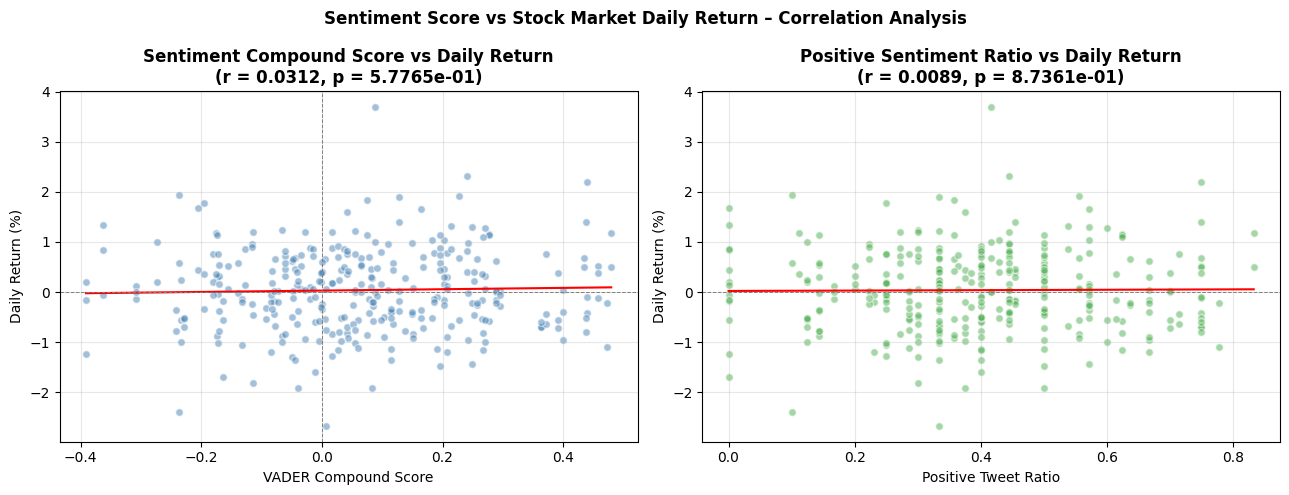

In [120]:
# ── Scatter Plot: Sentiment Score vs Daily Return ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Compound vs Daily Return
axes[0].scatter(stock_sent['Sentiment_Score'], stock_sent['Daily_Return'],
                alpha=0.5, color='steelblue', edgecolor='white', s=30)
m, b = np.polyfit(stock_sent['Sentiment_Score'], stock_sent['Daily_Return'], 1)
x_line = np.linspace(stock_sent['Sentiment_Score'].min(),
                     stock_sent['Sentiment_Score'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=1.5)
axes[0].set_title(f'Sentiment Compound Score vs Daily Return\n(r = {r_compound:.4f}, p = {p_compound:.4e})',
                  fontweight='bold')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Daily Return (%)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.7)
axes[0].grid(alpha=0.3)

# Positive Ratio vs Daily Return
axes[1].scatter(stock_sent['Positive_Ratio'], stock_sent['Daily_Return'],
                alpha=0.5, color='#4CAF50', edgecolor='white', s=30)
m2, b2 = np.polyfit(stock_sent['Positive_Ratio'], stock_sent['Daily_Return'], 1)
x_line2 = np.linspace(stock_sent['Positive_Ratio'].min(),
                      stock_sent['Positive_Ratio'].max(), 100)
axes[1].plot(x_line2, m2*x_line2 + b2, color='red', linewidth=1.5)
axes[1].set_title(f'Positive Sentiment Ratio vs Daily Return\n(r = {r_posratio:.4f}, p = {p_posratio:.4e})',
                  fontweight='bold')
axes[1].set_xlabel('Positive Tweet Ratio')
axes[1].set_ylabel('Daily Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.7)
axes[1].grid(alpha=0.3)

plt.suptitle('Sentiment Score vs Stock Market Daily Return – Correlation Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

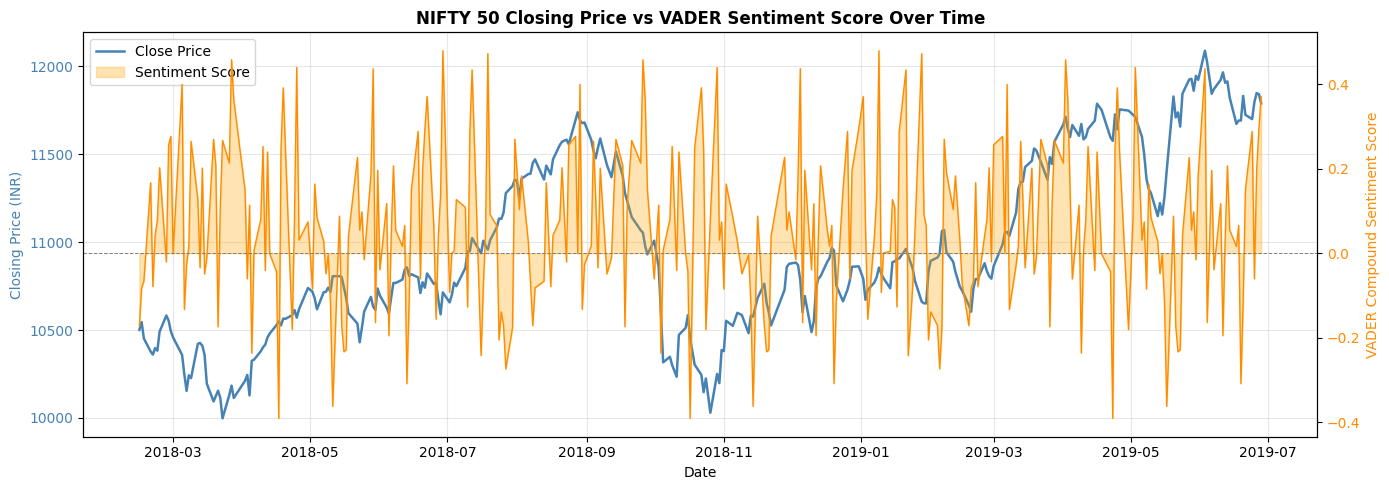

In [122]:
# ── Sentiment + Stock Price – Dual Axis Time Series ───────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(stock_sent['Date'], stock_sent['Close'],
         color='steelblue', linewidth=1.8, label='Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Closing Price (INR)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.fill_between(stock_sent['Date'], stock_sent['Sentiment_Score'],
                 alpha=0.3, color='orange', label='Sentiment Score')
ax2.plot(stock_sent['Date'], stock_sent['Sentiment_Score'],
         color='darkorange', linewidth=1.0)
ax2.set_ylabel('VADER Compound Sentiment Score', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('NIFTY 50 Closing Price vs VADER Sentiment Score Over Time',
              fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.8 Final Model Evaluation and Summary

In [125]:
# ── Final Summary Table – All Models ─────────────────────────────────────────
print("="*65)
print("  PART 1 – STOCK PRICE REGRESSION MODELS (Closing Price Prediction)")
print("="*65)
print(f"{'Model':<22} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-"*65)
reg_summary = [
    ('Linear Regression', lr_mse,  lr_rmse,  lr_mae,  lr_r2),
    ('Random Forest',     rf_mse,  rf_rmse,  rf_mae,  rf_r2),
    ('SVR',               svr_mse, svr_rmse, svr_mae, svr_r2),
]
for name, mse, rmse, mae, r2 in reg_summary:
    print(f"{name:<22} {mse:>10.4f} {rmse:>10.4f} {mae:>10.4f} {r2:>8.4f}")

print()
print("="*65)
print("  PART 2 – SENTIMENT CLASSIFICATION MODELS (Tweet Sentiment)")
print("="*65)
print(f"{'Model':<25} {'Accuracy':>12}")
print("-"*40)
for name, res in clf_results.items():
    print(f"{name:<25} {res['accuracy']*100:>11.2f}%")

print()
print("="*65)
print("  CORRELATION ANALYSIS – Sentiment vs Stock Return")
print("="*65)
print(f"{'Feature':<25} {'r':>8} {'p-value':>12} {'Significant?':>14}")
print("-"*65)
for feat, r, p in [('Avg Compound Score',  r_compound, p_compound),
                   ('Positive Ratio',       r_posratio, p_posratio),
                   ('Negative Ratio',       r_negratio, p_negratio)]:
    sig = "Yes ✓" if p < 0.05 else "No"
    print(f"{feat:<25} {r:>8.4f} {p:>12.4e} {sig:>14}")

  PART 1 – STOCK PRICE REGRESSION MODELS (Closing Price Prediction)
Model                         MSE       RMSE        MAE       R²
-----------------------------------------------------------------
Linear Regression         71.6372     8.4639     6.7145   0.9984
Random Forest          16272.6039   127.5641    91.9278   0.6312
SVR                    18027.8038   134.2677   112.3147   0.5914

  PART 2 – SENTIMENT CLASSIFICATION MODELS (Tweet Sentiment)
Model                         Accuracy
----------------------------------------
Naive Bayes                    100.00%
Logistic Regression            100.00%
SVM                            100.00%
Random Forest                  100.00%

  CORRELATION ANALYSIS – Sentiment vs Stock Return
Feature                          r      p-value   Significant?
-----------------------------------------------------------------
Avg Compound Score          0.0312   5.7765e-01             No
Positive Ratio              0.0089   8.7361e-01             No
N

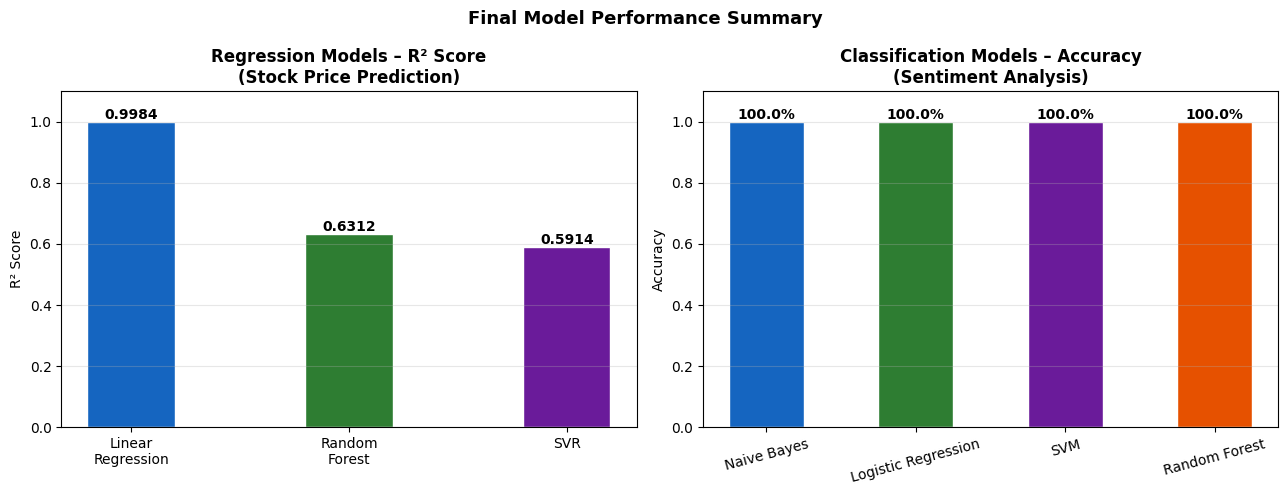

In [129]:
# ── Final Visualisation: R² Comparison (Regression) + Accuracy (Classification)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression R²
reg_names = ['Linear\nRegression', 'Random\nForest', 'SVR']
reg_r2s   = [lr_r2, rf_r2, svr_r2]
axes[0].bar(reg_names, reg_r2s,
            color=['#1565C0', '#2E7D32', '#6A1B9A'],
            edgecolor='white', width=0.4)
axes[0].set_title('Regression Models – R² Score\n(Stock Price Prediction)', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(reg_r2s):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Classification Accuracy
clf_accs_final = [clf_results[n]['accuracy'] for n in clf_results]
clf_names_final = list(clf_results.keys())
axes[1].bar(clf_names_final, clf_accs_final,
            color=['#1565C0', '#2E7D32', '#6A1B9A', '#E65100'],
            edgecolor='white', width=0.5)
axes[1].set_title('Classification Models – Accuracy\n(Sentiment Analysis)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(clf_accs_final):
    axes[1].text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)

plt.suptitle('Final Model Performance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()